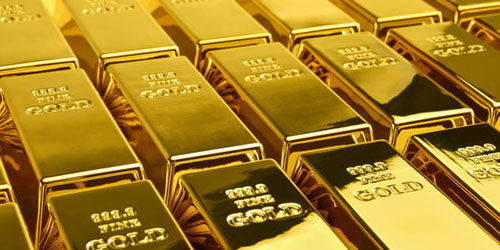

In [10]:
import IPython as ip
ip.display.Image("https://pakobserver.net/wp-content/uploads/2021/01/gold-5.jpg")

## Step 1 : Importing Modules

In [84]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score #root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns 
import warnings as w
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.linear_model import Ridge
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
w.filterwarnings('ignore')
print("Modules Loaded Successfully!")

Modules Loaded Successfully!


## Step 2 : Loading Datasets

In [20]:
df=pd.read_csv('Gold vs USDINR.csv')
df

,Date,USD_INR,Goldrate
0,2024-01-01,83.240601,"₹5,066.31"
1,2024-01-08,83.076103,"₹4,966.31"
2,2024-01-15,83.160599,"₹5,015.33"
3,2024-01-22,83.146103,"₹4,950.84"
4,2024-01-29,82.927597,"₹4,976.77"
5,2024-02-05,82.985298,"₹4,953.90"
6,2024-02-12,83.009598,"₹4,938.73"
7,2024-02-19,82.872299,"₹4,934.99"
8,2024-02-26,82.910400,"₹4,960.54"
9,2024-03-04,82.752296,"₹5,167.64"


## Step 3 : Performing EDA

In [21]:
df.head()

,Date,USD_INR,Goldrate
0,2024-01-01,83.240601,"₹5,066.31"
1,2024-01-08,83.076103,"₹4,966.31"
2,2024-01-15,83.160599,"₹5,015.33"
3,2024-01-22,83.146103,"₹4,950.84"
4,2024-01-29,82.927597,"₹4,976.77"


In [22]:
df.describe()

,USD_INR
count,53.000000
mean,83.717398
std,0.637302
min,82.752296
25%,83.301804
50%,83.544998
75%,83.988998
max,85.786598


In [23]:
df["Goldrate"] = df["Goldrate"].replace("₹",'',regex=True).replace(',','',regex=True).astype(float)

In [24]:
df.head()

,Date,USD_INR,Goldrate
0,2024-01-01,83.240601,5066.31
1,2024-01-08,83.076103,4966.31
2,2024-01-15,83.160599,5015.33
3,2024-01-22,83.146103,4950.84
4,2024-01-29,82.927597,4976.77


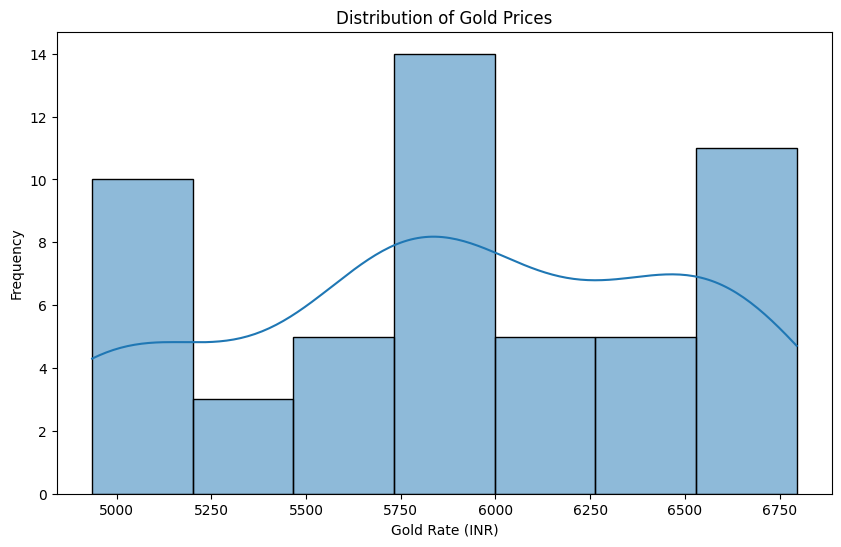

In [26]:
# Visualize the distribution of 'Goldrate'
plt.figure(figsize=(10, 6))
sns.histplot(df['Goldrate'], kde=True)
plt.title('Distribution of Gold Prices')
plt.xlabel('Gold Rate (INR)')
plt.ylabel('Frequency')
plt.show()

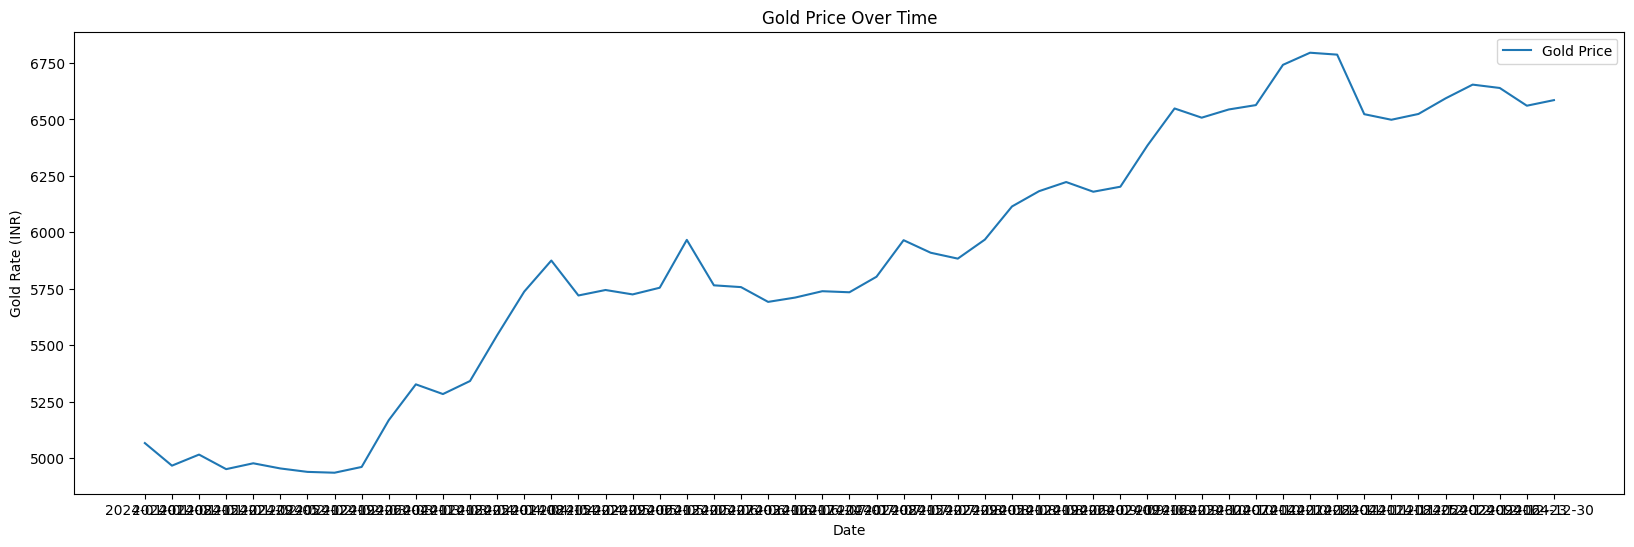

In [31]:
plt.figure(figsize=(20,6))
sns.lineplot(data=df, x='Date', y='Goldrate', label='Gold Price')
plt.title('Gold Price Over Time')
plt.xlabel('Date')
plt.ylabel('Gold Rate (INR)')
plt.show()

<Axes: ylabel='USD_INR'>

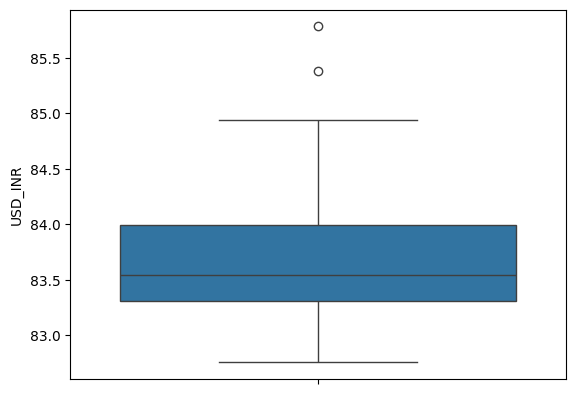

In [32]:
sns.boxplot(data=df['USD_INR'])

In [36]:

#remove outliers

# Calculate IQR for USD_INR
Q1 = df['USD_INR'].quantile(0.25)
Q3 = df['USD_INR'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers based on the bounds
df_cleaned = df[
    (df['USD_INR'] >= lower_bound) & (df['USD_INR'] <= upper_bound)
]

# Print the number of outliers removed
print(f"Number of outliers removed: {len(df) - len(df_cleaned)}")

Number of outliers removed: 2


<Axes: ylabel='USD_INR'>

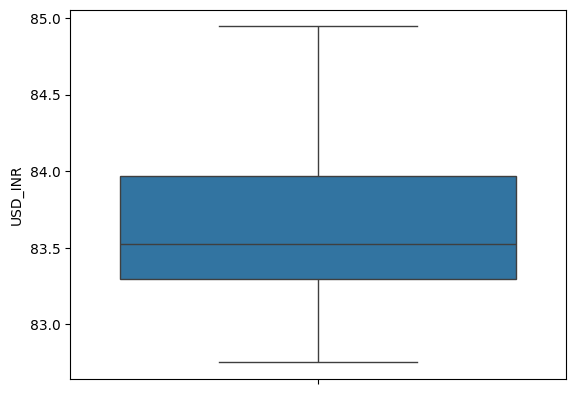

In [37]:

sns.boxplot(data=df_cleaned['USD_INR'])

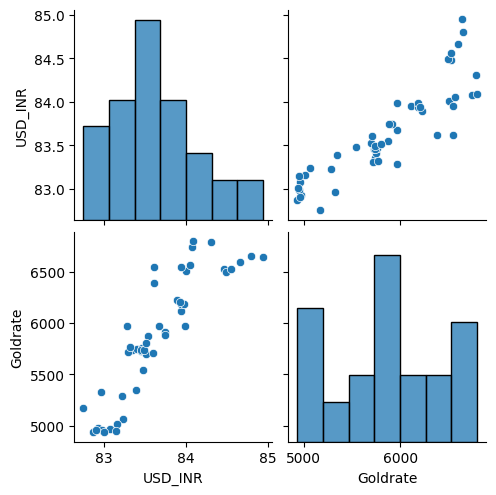

In [38]:

sns.pairplot(df_cleaned)

<Axes: xlabel='Goldrate', ylabel='USD_INR'>

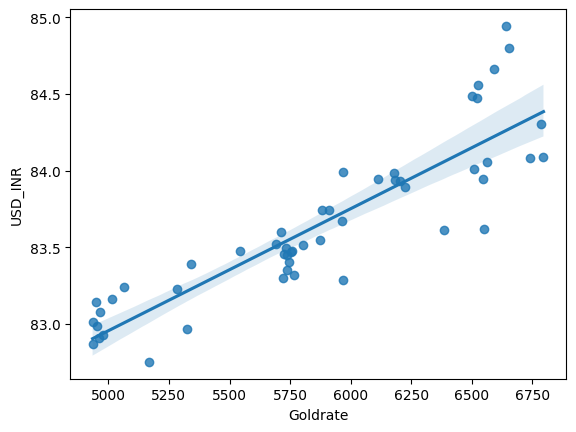

In [39]:
sns.regplot(x='Goldrate',y='USD_INR',data=df_cleaned)

##  Step 4: Feature Engineering

### Techniques Used

- **Extracted temporal features**  
  e.g., *day, month, year, day of the week* — to capture **seasonal and time-based trends**.

- **Standardized features**  
  Ensured all variables were on a **similar scale** before feeding them into machine learning models.

- **Implemented feature selection**  
  Retained only the **most important attributes** to improve **model efficiency and accuracy**.


In [40]:
X = df_cleaned[['USD_INR']]
y = df_cleaned[['Goldrate']]

In [41]:
print(X.shape)
print(y.shape)

(51, 1)
(51, 1)


In [42]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [43]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(40, 1)
(11, 1)
(40, 1)
(11, 1)


In [44]:
#standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
X_train_scaled

array([[-1.28057948e+00],
       [ 2.15516837e+00],
       [-1.10040558e+00],
       [ 1.71016575e+00],
       [-1.24934489e+00],
       [ 5.80053355e-01],
       [ 5.90584978e-01],
       [-2.63986902e-01],
       [ 1.90814640e+00],
       [-1.27948818e-01],
       [-1.56774633e+00],
       [-5.69667239e-01],
       [-2.21666410e-01],
       [ 1.25499179e+00],
       [-2.98865962e-01],
       [-7.06259609e-01],
       [-6.80831281e-01],
       [ 1.55905082e+00],
       [-1.76075567e-01],
       [ 5.07953312e-01],
       [-1.14454139e+00],
       [ 2.34228128e-01],
       [-1.34762630e-03],
       [-9.79610650e-01],
       [-5.34982180e-01],
       [-8.26139974e-01],
       [ 7.15550994e-01],
       [ 6.68685278e-01],
       [-1.69534864e-01],
       [ 7.96201058e-01],
       [-1.18032120e+00],
       [-2.58540948e-01],
       [-2.83428831e-01],
       [ 2.41489758e+00],
       [-5.97645330e-01],
       [-1.34978333e+00],
       [ 8.47057712e-01],
       [-4.83404938e-01],
       [ 1.0

In [46]:
X_test_scaled

array([[ 0.86467046],
       [ 0.60039603],
       [ 1.58537988],
       [-0.40402977],
       [-0.02514078],
       [ 0.67849631],
       [-0.37986245],
       [ 0.60458095],
       [-0.85246901],
       [ 0.23331354],
       [-0.25000479]])

##  Step 4: Model Training & Evaluation

###  Models Implemented

- **Linear Regression**  
  Served as a **baseline model** to compare performance.

- **Random Forest Regressor**  
  Applied **hyperparameter tuning** using `RandomizedSearchCV` to improve model accuracy and reduce overfitting.

- **ARIMA**  
  Implemented as a **time-series forecasting model** to capture **temporal dependencies and trends**.


### 1. Linear Regression

In [47]:
lin_reg = LinearRegression()

In [52]:
lin_reg.fit(X_train_scaled,y_train)

LinearRegression()

In [53]:
lin_reg.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [55]:
y_pred = lin_reg.predict(X_test_scaled)
print(y_pred)
print(y_test)

[[6303.91716248]
 [6165.06820038]
 [6682.57563976]
 [5637.34602291]
 [5836.4131137 ]
 [6206.10184462]
 [5650.04345372]
 [6167.26694494]
 [5401.73744228]
 [5972.20420554]
 [5718.27026614]]
    Goldrate
43   6795.35
40   6544.00
46   6498.43
12   5341.21
24   5710.88
31   5967.66
17   5744.34
32   6114.39
3    4950.84
30   5883.33
13   5543.85


In [57]:
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

Mean Squared Error: 75693.8314734317
Root Mean Squared Error: 275.1251196699998
R-squared: 0.7244658615036519


In [64]:
# Define the parameter grid for RandomizedSearchCV
param_grid = {
    'alpha': np.logspace(-4, 4, 50),  # Explore a wide range of alpha values
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],  # Different solvers
    'fit_intercept': [True, False]  # Include or exclude the intercept
}

# Create a Ridge regression model
ridge = Ridge()

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=ridge,
    param_distributions=param_grid,
    n_iter=10,  # Number of random parameter combinations to try
    cv=5,  # Number of cross-validation folds
    scoring='neg_mean_squared_error',  # Use negative MSE as the scoring metric
    n_jobs=-1,  # Use all available CPU cores
    random_state=42,  # Set a random state for reproducibility
    verbose=2  # Set verbosity for output
)

In [91]:
# Fit the RandomizedSearchCV object to your training data
random_search.fit(X_train_scaled, y_train)

# Print the best hyperparameters found
print("Best hyperparameters:", random_search.best_params_)

# Get the best model
best_ridge = random_search.best_estimator_

# Evaluate the best model on the test set
y_pred_ridge  = best_ridge.predict(X_test_scaled)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best hyperparameters: {'solver': 'saga', 'fit_intercept': True, 'alpha': np.float64(1.2067926406393288)}


In [92]:
# Calculate the metrics for the best model
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Best Model Mean Squared Error: {mse_best}")
print(f"Best Model Root Mean Squared Error: {rmse_best}")
print(f"Best Model R-squared: {r2_best}")

Best Model Mean Squared Error: 77666.20479855611
Best Model Root Mean Squared Error: 278.68657089740816
Best Model R-squared: 0.7172861987180247


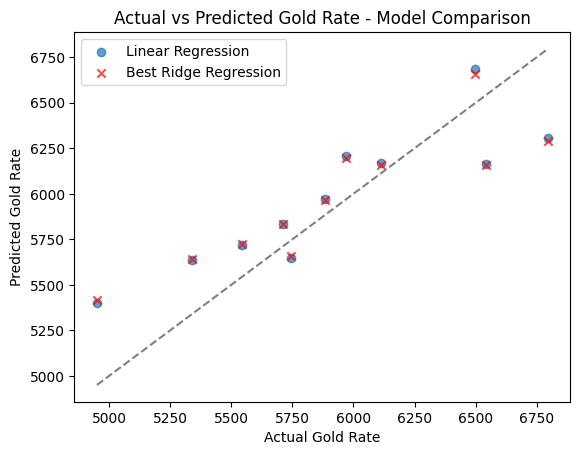

In [93]:
# comparing results of models through plots

import matplotlib.pyplot as plt

# Create a figure and an axes
fig, ax = plt.subplots()

# Plot the actual vs predicted values for the original linear regression model
ax.scatter(y_test, y_pred, label='Linear Regression', alpha=0.7)

# Plot the actual vs predicted values for the best Ridge regression model
ax.scatter(y_test, y_pred_best, label='Best Ridge Regression', alpha=0.7, marker='x', color='red')


# Add labels and title
ax.set_xlabel('Actual Gold Rate')
ax.set_ylabel('Predicted Gold Rate')
ax.set_title('Actual vs Predicted Gold Rate - Model Comparison')

# Add a legend
ax.legend()

# Add a diagonal line for reference
# Get the minimum and maximum values directly without indexing
min_value = min(y_test.min().values[0], y_pred.min(), y_pred_best.min())
max_value = max(y_test.max().values[0], y_pred.max(), y_pred_best.max())


ax.plot([min_value, max_value], [min_value, max_value], color='gray', linestyle='--')

# Show the plot
plt.show()

### 2. Random Forest Regressor

In [94]:
# using random forest regressor

# Initialize the RandomForestRegressor
rf_regressor = RandomForestRegressor(random_state=42)

# Define the parameter grid for RandomizedSearchCV (expanded for RandomForest)
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

In [95]:
# Initialize RandomizedSearchCV for RandomForest
random_search_rf = RandomizedSearchCV(
    estimator=rf_regressor,
    param_distributions=param_grid_rf,
    n_iter=10,  # Number of random combinations to try
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=2
)
     

In [96]:
# Fit the RandomForest model with RandomizedSearchCV
random_search_rf.fit(X_train_scaled, y_train.values.ravel()) # .ravel() to handle potential shape issues

# Print the best hyperparameters for RandomForest
print("Best hyperparameters for RandomForest:", random_search_rf.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best hyperparameters for RandomForest: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}


In [97]:
# Get the best RandomForest model
best_rf = random_search_rf.best_estimator_

# Predict using the best RandomForest model
y_pred_rf = best_rf.predict(X_test_scaled)

In [98]:
# Evaluate the best RandomForest model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - Mean Squared Error: {mse_rf}")
print(f"Random Forest - Root Mean Squared Error: {rmse_rf}")
print(f"Random Forest - R-squared: {r2_rf}")

Random Forest - Mean Squared Error: 81500.73831135004
Random Forest - Root Mean Squared Error: 285.4833415654056
Random Forest - R-squared: 0.703328061477292


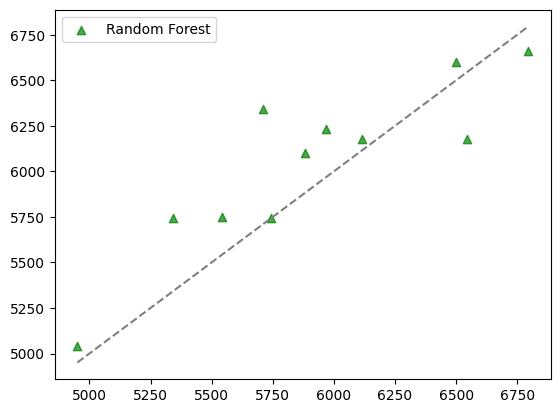

In [99]:
# ... (rest of your plotting code, modified to include Random Forest results)
fig, ax = plt.subplots()

# Plot for Random Forest
ax.scatter(y_test, y_pred_rf, label='Random Forest', alpha=0.7, marker='^', color='green')

# Update legend and limits (as before)
ax.legend()

min_value = min(y_test.min().values[0], y_pred.min(), y_pred_best.min(), y_pred_rf.min())
max_value = max(y_test.max().values[0], y_pred.max(), y_pred_best.max(), y_pred_rf.max())
ax.plot([min_value, max_value], [min_value, max_value], color='gray', linestyle='--')

### 3. Arima Model 

In [100]:
# Use arima model

# Prepare the data for ARIMA (using 'Goldrate' as the time series)
gold_prices = df_cleaned['Goldrate']

# Split data into training and testing sets
train_size = int(len(gold_prices) * 0.8)
train, test = gold_prices[0:train_size], gold_prices[train_size:len(gold_prices)]


In [101]:
# Fit the ARIMA model
# (p, d, q) are the order of the model. You might need to tune these parameters.
model = ARIMA(train, order=(5, 1, 0))  # Example order, adjust as needed
model_fit = model.fit()

In [102]:
# Make predictions
predictions = model_fit.predict(start=len(train), end=len(gold_prices)-1)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f'Test RMSE: {rmse}')

Test RMSE: 122.12107950979521


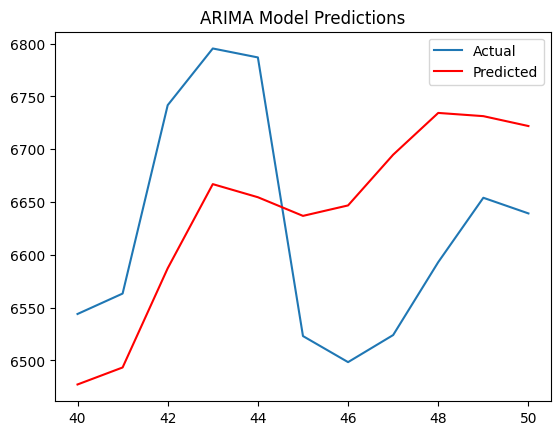

In [103]:
# Plot the results
plt.plot(test, label='Actual')
plt.plot(predictions, color='red', label='Predicted')
plt.legend()
plt.title('ARIMA Model Predictions')
plt.show()

## 5. Result and Evaluation

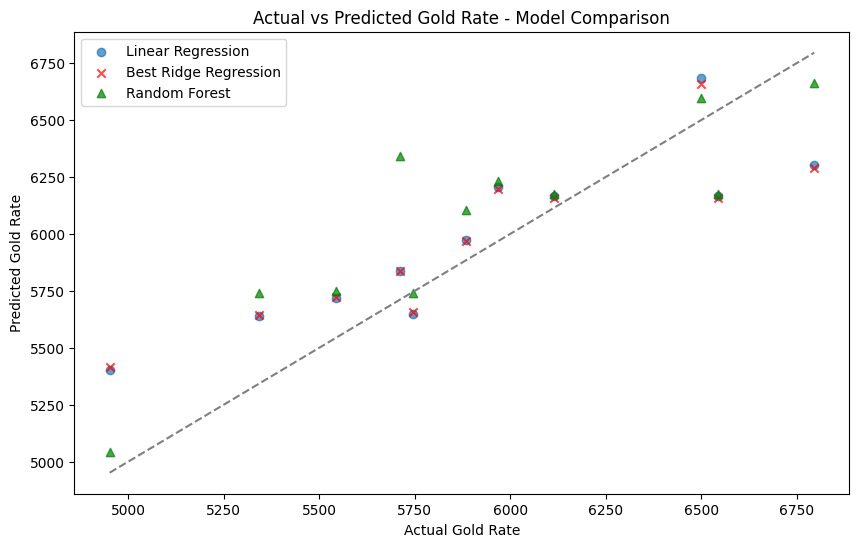

In [104]:
# compare linear and random forest regression models

# Create a figure and an axes for the comparison plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the actual vs predicted values for the original linear regression model
ax.scatter(y_test, y_pred, label='Linear Regression', alpha=0.7)

# Plot the actual vs predicted values for the best Ridge regression model
ax.scatter(y_test, y_pred_best, label='Best Ridge Regression', alpha=0.7, marker='x', color='red')

# Plot for Random Forest
ax.scatter(y_test, y_pred_rf, label='Random Forest', alpha=0.7, marker='^', color='green')

# Add labels, title, legend, and diagonal line (as before)
ax.set_xlabel('Actual Gold Rate')
ax.set_ylabel('Predicted Gold Rate')
ax.set_title('Actual vs Predicted Gold Rate - Model Comparison')
ax.legend()

min_value = min(y_test.min().values[0], y_pred.min(), y_pred_best.min(), y_pred_rf.min())
max_value = max(y_test.max().values[0], y_pred.max(), y_pred_best.max(), y_pred_rf.max())
ax.plot([min_value, max_value], [min_value, max_value], color='gray', linestyle='--')

plt.show()

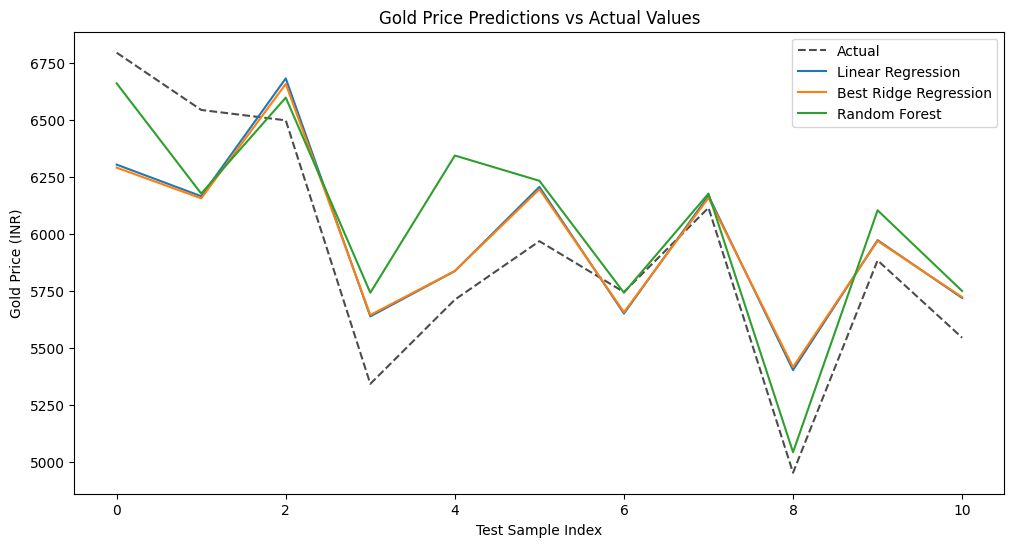

In [105]:
# Actual vs Predicted Data
y_test_values = range(len(y_test))  # X-axis (Sample Index)
y_actual = y_test.values

# Model Predictions
predictions = {
    "Linear Regression": y_pred,
    "Best Ridge Regression": y_pred_ridge,
    "Random Forest": y_pred_rf,
}

# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test_values, y_actual, label="Actual", linestyle='dashed', color='black', alpha=0.7)

for model, y_pred in predictions.items():
    plt.plot(y_test_values, y_pred, label=model)

plt.legend()
plt.title("Gold Price Predictions vs Actual Values")
plt.xlabel("Test Sample Index")
plt.ylabel("Gold Price (INR)")
plt.show()

In [106]:
# Create a DataFrame for easy comparison of metrics
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Best Ridge Regression', 'Random Forest'],
    'MSE': [mse, mse_best, mse_rf],
    'RMSE': [rmse, rmse_best, rmse_rf],
    'R-squared': [r2, r2_best, r2_rf]
})

results_df

,Model,MSE,RMSE,R-squared
0,Linear Regression,75693.831473,122.121080,0.724466
1,Best Ridge Regression,77666.204799,278.686571,0.717286
2,Random Forest,81500.738311,285.483342,0.703328


## step 6 : Save the Models 

In [108]:
# save the models
import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(lin_reg, 'Regression_model.pkl')
joblib.dump(best_ridge, 'best_ridge_model.pkl')
joblib.dump(best_rf, 'best_random_forest_model.pkl')

print("Models saved successfully.")

Models saved successfully.


In [109]:
def predict_gold_rate(usd_inr_value):
    """
    Predicts the gold rate based on the USD/INR exchange rate using a pre-trained model.

    Args:
        usd_inr_value (float): The USD/INR exchange rate.

    Returns:
        float: The predicted gold rate.
    """
    try:
        # Load the pre-trained scaler and model
        scaler = joblib.load('scaler.pkl')
        model = joblib.load('Regression_model.pkl')  # Use the best model

        # Reshape the input for prediction
        usd_inr_scaled = scaler.transform(np.array([[usd_inr_value]]))

        # Make the prediction
        predicted_gold_rate = model.predict(usd_inr_scaled)

        return predicted_gold_rate[0][0]  # Extract the predicted value

    except FileNotFoundError:
        return "Error: Model files not found. Please ensure 'scaler.pkl' and 'best_ridge_model.pkl' are in the same directory."
    except Exception as e:
        return f"An error occurred: {e}"

In [113]:
import gradio as gr
iface = gr.Interface(
    fn=predict_gold_rate,
    inputs=gr.Number(label="USD/INR Exchange Rate"),
    outputs= gr.Number(label="output"),
    title="Gold Rate Prediction🥇",
    description="Enter the USD/INR exchange rate to predict the gold rate.",
)

iface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
Created dataset file at: .gradio\flagged\dataset1.csv

Could not create share link. Missing file: C:\Users\Govind Ahuja\.cache\huggingface\gradio\frpc\frpc_windows_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_windows_amd64.exe
2. Rename the downloaded file to: frpc_windows_amd64_v0.3
3. Move the file to this location: C:\Users\Govind Ahuja\.cache\huggingface\gradio\frpc


In [112]:
# pip install gradio

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/63.5 MB ? eta -:--:--
   - -------------------------------------- 2.1/63.5 MB 10.9 MB/s eta 0:00:06
   -- ------------------------------------- 4.2/63.5 MB 10.4 MB/s eta 0:00:06
   --- ------------------------------------ 6.3/63.5 MB 10.2 MB/s eta 0:00:06
   ----- ---------------------------------- 8.9/63.5 MB 10.7 MB/s eta 0:00:06
   ------ --------------------------------- 11.0/63.5 MB 10.7 MB/s eta 0:00:05
   -------- ------------------------------- 13.4/63.5 MB 10.6 MB/s eta 0:00:05
   --------- ------------------------------ 15.5/63.5 MB 10.5 MB/s eta 0:00:05
   ---------- ----------------------------- 17.0/63.5 MB 10.1 MB/s eta 0:00:05
   ----------- ---------------------------- 18.9/63.5 MB 10.0 MB/s eta 0:00:05
   ------------- -------------------------- 21.2/63.5 MB 10.1 MB/s eta 0:00:05
   -------------- ------------------------- 23.1/63.5 MB 10.0 MB/s

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
